# VGG11 - Individual Baseline Run


In [ ]:
import sys
import os

import torch

sys.path.append(os.path.abspath("../src"))

from models import VGG11
from data import prepare_full_dataframe, prepare_data
from train import run_training_pipeline, run_smoke_test
from utils import (
    get_device,
    print_model_overrides,
)
import config

print(f"Python:         {sys.executable}")
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")


Python:         c:\Users\profb\PROJECTS\cxr-model-benchmark\.venv\Scripts\python.exe
PyTorch:        2.11.0+cu128
CUDA available: True
GPU:            NVIDIA GeForce RTX 5090 Laptop GPU


In [2]:
dataset_path = config.DATASET_PATH
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print(f"Total images:    {len(df)}")
print(f"Unique patients: {df['Patient ID'].nunique()}")

Dataset location: C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays
Total images:    112120
Unique patients: 30805


In [3]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [ ]:
train_loader, val_loader, test_loader = prepare_data(df, model_name="VGG11")
print("Train transforms:", train_loader.dataset.transform)
device = get_device()


Using CUDA (GPU)


## Smoke Test


In [5]:
run_smoke_test(
    model_name="VGG11",
    model_builder=lambda: VGG11(num_classes=2, in_channels=1),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
)


=== Smoke test: VGG11 (epochs=1, patience=1, batches=1) ===

=== Training VGG11 ===

=== Run Configuration ===
Model: VGG11
Training: epochs=1, patience=3, batch_size=256, image_size=256, seed=42
Precision/Memory: amp_enabled=True, amp_dtype=bf16, channels_last(global=True, override=None, effective=True)
Optimization: layerwise_lr_enabled=True, uses_param_groups=True, freeze_backbone_enabled=True, freeze_backbone_epochs=1, lr=0.0001, backbone_lr=3e-05, head_lr=0.0002, weight_decay=5e-05, label_smoothing=0.03
Scheduler: enabled=True, type=warmup_cosine, start_epoch=1, warmup_epochs=0, warmup_start_factor=0.4, cosine_t_max=12, min_lr=1e-06, steps_per_epoch=1
Checkpoint Resume: False
Model Overrides: {'patience': 3, 'backbone_lr': 3e-05, 'head_lr': 0.0002, 'freeze_backbone_epochs': 1, 'scheduler_cosine_t_max': 12}
Starting fresh training (resume disabled): c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\checkpoints\best_vgg11\latest.pt
AMP enabled (bf16, grad scaler: off)
channels_la

Train Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

  VRAM a/r/p: 1.90G(7.9%)/6.67G(27.9%)/6.64G(27.8%)


Val Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/1 | ETA (Remaining): 00:00:00 | Total ETA: 00:00:04
  Train Loss: 0.7990 | Train Acc: 0.4258
  Val Loss: 1.7416 | Val Acc: 0.4648
  Val Precision: 0.4648
  Val Recall: 1.0000 | Val F1: 0.6347
  Val AUPRC: 0.5405
  Backbone LR: 2.95059e-05 | Head LR: 0.00019661
  Optimizer: AdamW | Weight Decay: 5e-05 | No-Decay Groups: 2
------------------------------------------------------------
Saved best model to c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\models\best_vgg11.pt
------------------------------------------------------------


Test:   0%|          | 0/1 [00:00<?, ?it/s]

({'model': 'VGG11',
  'epochs': 1,
  'batch_size': 256,
  'image_size': 256,
  'test_loss': 1.572373867034912,
  'accuracy': 0.51953125,
  'precision': 0.51953125,
  'recall': 1.0,
  'f1': 0.6838046272493573,
  'auprc': 0.6143444693187866},
 {'train_loss': [0.7990205883979797],
  'train_acc': [0.42578125],
  'val_loss': [1.7415924072265625],
  'val_acc': [0.46484375],
  'val_precision': [0.46484375],
  'val_recall': [1.0],
  'val_f1': [0.6346666666666667],
  'val_auprc': [0.5404537134615585],
  'lr': [0.00019660961971576228],
  'lr_backbone': [2.950592448119149e-05],
  'lr_head': [0.00019660961971576228],
  'backbone_frozen': [True],
  'vram_peak_pct': [27.78526889622152],
  'best_epoch': 1})

## Training


### Function Definitions


In [ ]:
run_results = []
baseline_auprc = 0.686

from notebook_experiment_runner import (
    cleanup_training_artifacts,
    print_planned_run_configuration,
    run_seed_experiment,
)


seed_bank = tuple(config.TUNING_OVERRIDES.get("VGG11", {}).get("seed_bank", [16, 32, 64]))
epoch_log_file = "../outputs/experiment_outputs/vgg11_epoch_metrics.log"

def run_vgg_experiment(seeds=seed_bank, live_plot=True, reset_results=False, reset_epoch_log=True):
    run_seed_experiment(
        run_results=run_results,
        baseline_auprc=baseline_auprc,
        model_builder=lambda: VGG11(num_classes=2, in_channels=1),
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        model_name="VGG11",
        seeds=seeds,
        live_plot=live_plot,
        reset_results=reset_results,
        epoch_log_file=epoch_log_file,
        reset_epoch_log=reset_epoch_log,
    )


### Run


In [ ]:
print_planned_run_configuration(
    model_name="VGG11",
    model_builder=lambda: VGG11(num_classes=2, in_channels=1),
    device=device,
    resume_from_checkpoint=False,
)


run_vgg_experiment()


In [9]:
print("\n=== Run Snapshot ===")
print(f"Best epoch: {best_epoch if best_epoch is not None else 'N/A'}")
if best_val_auprc is not None:
    print(f"Best val AUPRC (Delta baseline): {best_val_auprc:.4f} ({best_val_auprc - baseline_auprc:+.4f})")
else:
    print("Best val AUPRC: N/A")

test_auprc = metrics.get("auprc")
if test_auprc is not None:
    print(f"Test AUPRC: {float(test_auprc):.4f}")
else:
    print("Test AUPRC: N/A")

print("\n=== Run Summary ===")
print(f"Model: {metrics.get('model', 'VGG11')}")
print(f"Epochs: {metrics.get('epochs', len(history.get('train_loss', [])))}")

for key in ["test_loss", "accuracy", "precision", "recall", "f1", "auprc"]:
    value = metrics.get(key)
    if value is None:
        print(f"{key}: N/A")
    else:
        print(f"{key}: {float(value):.4f}")


=== Run Snapshot ===
Best epoch: 3
Best val AUPRC (Delta baseline): 0.7001 (+0.0141)
Test AUPRC: 0.7111

=== Run Summary ===
Model: VGG11
Epochs: 6
test_loss: 0.5877
accuracy: 0.7073
precision: 0.6848
recall: 0.6792
f1: 0.6820
auprc: 0.7111


#### Cleanup

In [10]:
cleanup()

CUDA cache cleared.
Cleanup complete. Loaders preserved for next run.


### Run #2

#### Seed Setting

In [11]:
# 16, 32, 64
seed = 32

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

#### Training

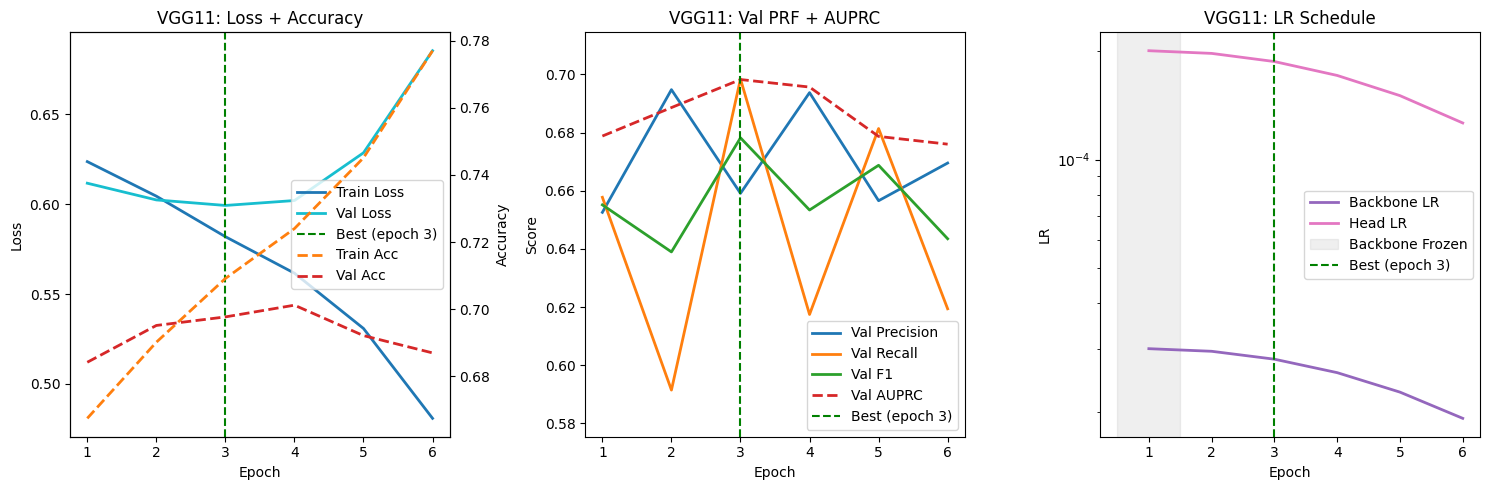

Early stopping at epoch 6 (patience 3 exceeded)


Test:   0%|          | 0/64 [00:00<?, ?it/s]

Run Seed = 32 complete: best_epoch=3, best_val_auprc=0.6982291936582595


In [12]:
print(f"\n=== Run #2 | seed={seed} ===")
metrics, history, best_epoch, best_val_auprc = run_full_training(seed=seed)

#### Metrics

In [13]:
print("\n=== Run Snapshot ===")
print(f"Best epoch: {best_epoch if best_epoch is not None else 'N/A'}")
if best_val_auprc is not None:
    print(f"Best val AUPRC (Delta baseline): {best_val_auprc:.4f} ({best_val_auprc - baseline_auprc:+.4f})")
else:
    print("Best val AUPRC: N/A")

test_auprc = metrics.get("auprc")
if test_auprc is not None:
    print(f"Test AUPRC: {float(test_auprc):.4f}")
else:
    print("Test AUPRC: N/A")

print("\n=== Run Summary ===")
print(f"Model: {metrics.get('model', 'VGG11')}")
print(f"Epochs: {metrics.get('epochs', len(history.get('train_loss', [])))}")

for key in ["test_loss", "accuracy", "precision", "recall", "f1", "auprc"]:
    value = metrics.get(key)
    if value is None:
        print(f"{key}: N/A")
    else:
        print(f"{key}: {float(value):.4f}")


=== Run Snapshot ===
Best epoch: 3
Best val AUPRC (Delta baseline): 0.6982 (+0.0122)
Test AUPRC: 0.7072

=== Run Summary ===
Model: VGG11
Epochs: 6
test_loss: 0.5936
accuracy: 0.7018
precision: 0.6638
recall: 0.7185
f1: 0.6900
auprc: 0.7072


#### Cleanup

In [14]:
cleanup()

CUDA cache cleared.
Cleanup complete. Loaders preserved for next run.


### Run #3

#### Seed Setting

In [15]:
# 16, 32, 64
seed = 64

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

#### Training

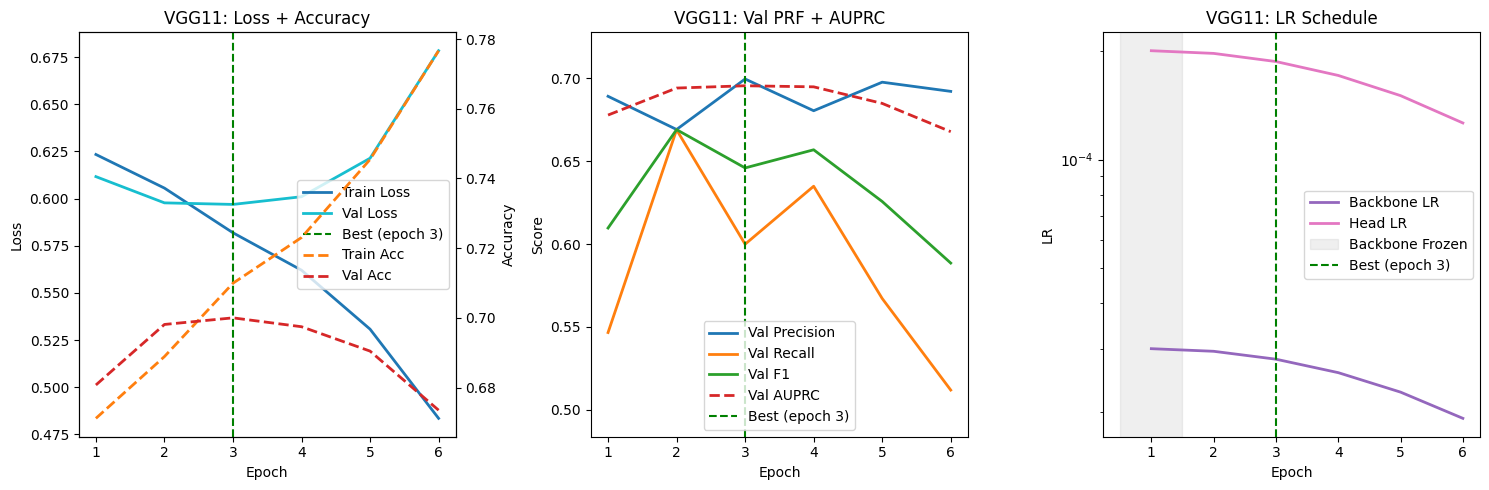

Early stopping at epoch 6 (patience 3 exceeded)


Test:   0%|          | 0/64 [00:00<?, ?it/s]

Run Seed = 64 complete: best_epoch=3, best_val_auprc=0.6954588666522404


In [16]:
print(f"\n=== Run #3 | seed={seed} ===")
metrics, history, best_epoch, best_val_auprc = run_full_training(seed=seed)

#### Metrics

In [17]:
print("\n=== Run Snapshot ===")
print(f"Best epoch: {best_epoch if best_epoch is not None else 'N/A'}")
if best_val_auprc is not None:
    print(f"Best val AUPRC (Delta baseline): {best_val_auprc:.4f} ({best_val_auprc - baseline_auprc:+.4f})")
else:
    print("Best val AUPRC: N/A")

test_auprc = metrics.get("auprc")
if test_auprc is not None:
    print(f"Test AUPRC: {float(test_auprc):.4f}")
else:
    print("Test AUPRC: N/A")

print("\n=== Run Summary ===")
print(f"Model: {metrics.get('model', 'VGG11')}")
print(f"Epochs: {metrics.get('epochs', len(history.get('train_loss', [])))}")

for key in ["test_loss", "accuracy", "precision", "recall", "f1", "auprc"]:
    value = metrics.get(key)
    if value is None:
        print(f"{key}: N/A")
    else:
        print(f"{key}: {float(value):.4f}")


=== Run Snapshot ===
Best epoch: 3
Best val AUPRC (Delta baseline): 0.6955 (+0.0095)
Test AUPRC: 0.7080

=== Run Summary ===
Model: VGG11
Epochs: 6
test_loss: 0.5922
accuracy: 0.7065
precision: 0.7075
recall: 0.6219
f1: 0.6619
auprc: 0.7080


#### Cleanup

In [18]:
cleanup()

CUDA cache cleared.
Cleanup complete. Loaders preserved for next run.


## Complete Metrics

In [19]:
import pandas as pd

# Create summary dataframe
summary_df = pd.DataFrame([
    {
        "Seed": r["seed"],
        "Best Epoch": r["best_epoch"],
        "Best Val AUPRC": f"{r['best_val_auprc']:.4f}" if r['best_val_auprc'] else "N/A",
        "Delta": f"{r['delta']:.4f}" if r['delta'] else "N/A",
    }
    for r in run_results
])

print("\n=== Run Comparison ===")
print(summary_df.to_string(index=False))

# Calculate mean across runs
if len(run_results) > 1:
    valid_auprc = [r["best_val_auprc"] for r in run_results if r["best_val_auprc"]]
    mean_auprc = sum(valid_auprc) / len(valid_auprc)
    mean_delta = sum(r["delta"] for r in run_results if r["delta"] is not None) / len(valid_auprc)
    std_auprc = (sum((x - mean_auprc)**2 for x in valid_auprc) / len(valid_auprc))**0.5
    print(f"\nMean Val AUPRC: {mean_auprc:.4f} ({mean_delta:+.4f})")
    print(f"Std Dev: {std_auprc:.4f}")


=== Run Comparison ===
 Seed  Best Epoch Best Val AUPRC  Delta
   16           3         0.7001 0.0141
   32           3         0.6982 0.0122
   64           3         0.6955 0.0095

Mean Val AUPRC: 0.6979 (+0.0119)
Std Dev: 0.0019
